### Installing relevant packages

In [ ]:
%pip install h5py h5netcdf cdsapi pandas numpy pyproj pygrib xarray s3fs dataretrieval google-cloud-storage matplotlib haversine  geopandas shapely resource boto3 botocore zarr fsspec 

### Importing packages

In [ ]:
import os
import cdsapi
from scipy.signal import correlate
import pandas as pd
import shutil
import numpy as np
import pyproj
import pygrib
import xarray as xr
import s3fs
import dataretrieval.nwis as nwis
from google.cloud import storage
from datetime import datetime, timedelta, date
import json
from haversine import haversine, Unit
import warnings
import geopandas as gpd
from shapely.geometry import Point
import resource
from pyproj import Transformer
import pickle
from collections import defaultdict
import subprocess
from pathlib import Path
import requests
from pytz import utc
import matplotlib.pyplot as plt
from pandas import Timestamp
import matplotlib.dates as mdates
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import botocore
from math import sqrt
from concurrent.futures import ThreadPoolExecutor
import fsspec


# Setting up root directory

In [ ]:
os.chdir('/home/jaguir26/projects/')

In [ ]:
# Define a function to create a directory for a given site code
def create_directory_ID(base_path, folder_id):
    directory_path = os.path.join(base_path, f"{folder_id}")
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
    return directory_path

# Define a function to create a directory for a given site code
def create_directory_NAME(base_path, folder_name):
    directory_path = os.path.join(base_path, folder_name)
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
    return directory_path

## Creating main directories

In [ ]:
base_path = os.getcwd()
directory_path_project = create_directory_NAME(base_path, 'Project')

base_path = directory_path_project
directory_path_input = create_directory_NAME(base_path, 'Input')
directory_path_output = create_directory_NAME(base_path, 'Output')

base_path = directory_path_input
directory_path_input_id_river = create_directory_NAME(base_path, 'ID_River')
directory_path_nws_coord = create_directory_NAME(base_path, 'NWS-Coordinates')
directory_path_retro = create_directory_NAME(base_path, 'Retrospective_Analysis')
directory_path_input_exAL = create_directory_NAME(base_path, 'exAL')

base_path = directory_path_retro
directory_path_retro_nws = create_directory_NAME(base_path, 'NWS')
directory_path_retro_glofas = create_directory_NAME(base_path, 'GLOFAS')

base_path = directory_path_input_exAL
directory_path_input_covariates = create_directory_NAME(base_path, 'covariates')
directory_path_input_model = create_directory_NAME(base_path, 'model_outputs')
directory_path_input_parameters = create_directory_NAME(base_path, 'parameters')
directory_path_input_R_script= create_directory_NAME(base_path, 'R_script')

base_path = directory_path_output
directory_path_output_id_river = create_directory_NAME(base_path, 'ID_River')


## USGS Data Retrieval (station dependent)

In [ ]:
# Constants
CFSToCMS_CONVERSION_FACTOR = 0.0283168466

# Define time range
start_usgs = '1979-01-01'

today = datetime.today()
# Format it as YYYY-MM-DD
end_usgs = today.strftime('%Y-%m-%d')

# Convert end date to datetime object and get start date for forecast
end_usgs_datetime = datetime.strptime(end_usgs, '%Y-%m-%d')
start_forecast_datetime = end_usgs_datetime - timedelta(days=1)
start_forecast = start_forecast_datetime.strftime('%Y-%m-%d')

# Specify the USGS site code
site_code = '11160500'

# Fetch daily data for the site
df = nwis.get_record(sites=site_code, service='dv', parameterCd='00060', statCd='00003',
                     start=start_usgs, end=end_usgs)

# Log-transform the flow data; we add 1 to handle cases where the value is 0
df['log_discharge'] = np.log(df['00060_Mean'].astype(float) + 1)
# Keep only the relevant column
df = df[['log_discharge']]
# Reverse the log transformation to get back the discharge in cfs
df['discharge_cfs'] = np.exp(df['log_discharge']) - 1
# Convert discharge from cfs to cms
df['discharge_cms'] = df['discharge_cfs'] * CFSToCMS_CONVERSION_FACTOR
# Optionally, log-transform the discharge in cms
df['log_discharge_cms'] = np.log(df['discharge_cms'] + 1)

## Retriving Station's Location

In [ ]:
# Fetch metadata for the USGS site without specifying fields
site_info = nwis.get_record(sites=site_code, service='site')
station_name = site_info['station_nm'][0] 

# Extract latitude and longitude
latitude = float(site_info['dec_lat_va'][0])
longitude = float(site_info['dec_long_va'][0])

# Combine into a single target_location tuple
target_location = (latitude, longitude)
target_lat, target_lon = target_location
print(f"The coordinates for site {site_code} are {target_location}")

## Forecast Start Date:

In [ ]:
# start_forecast = '2022-12-26'
start_forecast = '2024-12-14'

In [ ]:
def filter_dataframe(df, start_forecast, pre_days, post_days):
    """
    Filter the DataFrame based on the forecast start date and the number of days before and after.

    Parameters:
    - df: DataFrame to filter
    - start_forecast: Start date of the forecast (string in 'YYYY-MM-DD' format)
    - pre_days: Number of days before the forecast start date
    - post_days: Number of days after the forecast start date

    Returns:
    - Filtered DataFrame
    """
    # Convert start forecast to datetime object
    start_forecast_dt = datetime.strptime(start_forecast, '%Y-%m-%d')

    # Calculate the start and end dates for filtering
    start_filter_dt = start_forecast_dt - timedelta(days=pre_days)
    end_filter_dt = start_forecast_dt + timedelta(days=post_days)

    # Convert dates back to string
    start_filter_str = start_filter_dt.strftime('%Y-%m-%d')
    end_filter_str = end_filter_dt.strftime('%Y-%m-%d')

    # Filter the DataFrame
    return df.loc[start_filter_str:end_filter_str]

# Applying the function to different forecast types
df_filtered = filter_dataframe(df, start_forecast, 10, 45)
df_filtered_s = filter_dataframe(df, start_forecast, 30, 270)
df_filtered_rf = filter_dataframe(df, start_forecast, 30, 270)

def filter_dataframe(df, start_forecast, pre_days, post_days):
    start_forecast_dt = datetime.strptime(start_forecast, '%Y-%m-%d')
    start_filter_dt = start_forecast_dt - timedelta(days=pre_days)
    end_filter_dt = start_forecast_dt + timedelta(days=post_days)
    return df.loc[start_filter_dt.strftime('%Y-%m-%d'):end_filter_dt.strftime('%Y-%m-%d')]



In [ ]:
def convert_date_format(date_str):
    """
    Convert a date string from 'YYYY-MM-DD' to 'YYYYMMDD'
    
    Parameters:
        date_str (str): Date string in 'YYYY-MM-DD' format
    
    Returns:
        str: Date string in 'YYYYMMDD' format
    """
    return date_str.replace("-", "")

# Example usage
start_forecast_joint = convert_date_format(start_forecast)

## Creating dependent directories

In [ ]:
# Input Dependent
base_path = directory_path_input_id_river
directory_path_input_ID = create_directory_ID(base_path, site_code)
base_path = directory_path_input_ID
directory_path_input_id_river_frsct_date = create_directory_NAME(base_path, 'Start_Forecast_Date')
directory_path_input_id_river_csv = create_directory_NAME(base_path, 'USGS_csv')
base_path = directory_path_input_id_river_frsct_date
directory_input_id_frsc = create_directory_ID(base_path, start_forecast_joint)

# Output Dependent
base_path = directory_path_output_id_river
directory_path_output_ID = create_directory_ID(base_path, site_code)
base_path = directory_path_output_ID
directory_path_output_id_river_frsct_date = create_directory_NAME(base_path, 'Start_Forecast_Date')
base_path = directory_path_output_id_river_frsct_date
directory_output_id_frsc  = create_directory_ID(base_path, start_forecast_joint)

# Forecasts (Inputs)
base_path = directory_input_id_frsc
directory_glofas_frsc = create_directory_NAME(base_path, 'GLOFAS_Forecasts')
directory_nws_frsc = create_directory_NAME(base_path, 'NWS_Forecasts')

base_path = directory_glofas_frsc
directory_glofas_frsc_med = create_directory_NAME(base_path, 'Medium_Range')
directory_glofas_frsc_seas = create_directory_NAME(base_path, 'Seasonal_Range')
directory_glofas_frsc_rf = create_directory_NAME(base_path, 'Reforecast_Range')

base_path = directory_nws_frsc
directory_nws_frsc_med = create_directory_NAME(base_path, 'Medium_Range')
directory_nws_frsc_long = create_directory_NAME(base_path, 'Long_Range')

# Model outputs and figures (Outputs)
base_path = directory_output_id_frsc
directory_path_model_output = create_directory_NAME(base_path, 'exAL_output')
directory_path_figures= create_directory_NAME(base_path, 'Figures')

### Up to date - USGS Figure

In [ ]:
# Modify the save path to include the new directory
today_date = datetime.now().strftime("%Y%m%d")
save_path = os.path.join(directory_path_figures, f"station_up_to_{today_date}.png")



# Create a new figure
plt.figure(figsize=(30, 6))
# Plotting
plt.plot(np.array(df.index), np.array(df['log_discharge_cms']), marker='o', linestyle='--', color='forestgreen', markersize=2, alpha=1)
# Adding labels and grid
plt.xlabel(' ')
plt.ylabel('Log Discharge (cms)')
# Set the plot title using the fetched station name
plt.title(f'{station_name} - (USGS)')
plt.grid(True)
# Save the figure before showing it
plt.savefig(save_path)
# Show the plot
plt.show()
print(f"Figure saved at {save_path}")


### Pyro.ai

In [ ]:
df.index

In [ ]:
# Install PyTorch first. Adjust this based on your system and requirements.
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# Install Pyro using pip
%pip install pyro-ppl


INFO 	 step    0 loss = 0.162962


INFO 	 step  100 loss = 0.128565
INFO 	 step  200 loss = 0.129002
INFO 	 step  300 loss = 0.127403
INFO 	 step  400 loss = 0.127314
INFO 	 step  500 loss = 0.128332
INFO 	 step  600 loss = 0.127345
INFO 	 step  700 loss = 0.127422
INFO 	 step  800 loss = 0.127579
INFO 	 step  900 loss = 0.12767


timescale = 17.94
trans_scale = 0.2626
obs_scale = 0.05654
CRPS = 0.5317


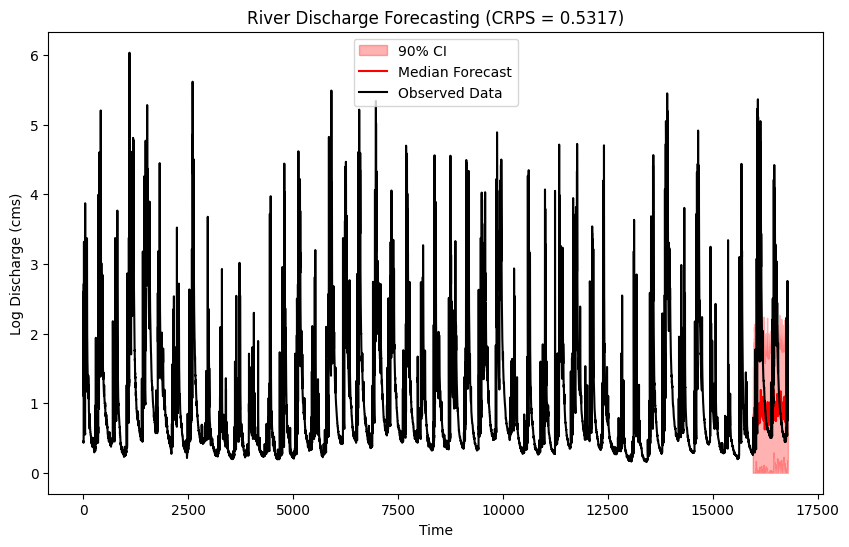

In [ ]:
import math
import torch
import pyro
import pyro.distributions as dist
import pyro.poutine as poutine
from pyro.contrib.forecast import ForecastingModel, Forecaster, eval_crps
from pyro.ops.tensor_utils import periodic_repeat
from pyro.ops.stats import quantile
import matplotlib.pyplot as plt
import pandas as pd

# Ensure Pyro version is compatible
assert pyro.__version__.startswith("1.9.1")
pyro.set_rng_seed(42)

# Load your dataset
# Assuming df has 'log_discharge_cms' as the target column and a datetime index
# df = pd.read_csv("path_to_your_file.csv", parse_dates=True, index_col=0)
data = torch.tensor(df['log_discharge_cms'].values, dtype=torch.float32).unsqueeze(-1)

# Parameters
T = data.size(0)  # Total length of the dataset
T_train = int(T * 0.95)  # 80% training split
T_test = T - T_train  # 20% testing split
means = data[:T_train].mean(dim=0)  # Calculate mean for seasonality modeling
covariates = torch.zeros(T, 0)  # Placeholder for any external covariates

# Define the Forecasting Model
class RiverDischargeModel(ForecastingModel):
    def model(self, zero_data, covariates):
        duration = zero_data.size(-2)

        # Periodic mean for seasonality
        prediction = periodic_repeat(means, duration, dim=-1).unsqueeze(-1)

        # Initial state distribution
        init_dist = dist.Normal(0, 10).expand([1]).to_event(1)

        # Transition dynamics
        timescale = pyro.sample("timescale", dist.LogNormal(math.log(24), 1))
        trans_matrix = torch.exp(-1 / timescale)[..., None, None]
        trans_scale = pyro.sample("trans_scale", dist.LogNormal(-0.5 * math.log(24), 1))
        trans_dist = dist.Normal(0, trans_scale.unsqueeze(-1)).to_event(1)

        # Observation noise
        obs_matrix = torch.tensor([[1.0]])
        obs_scale = pyro.sample("obs_scale", dist.LogNormal(-2, 1))
        obs_dist = dist.Normal(0, obs_scale.unsqueeze(-1)).to_event(1)

        # Define GaussianHMM
        noise_dist = dist.GaussianHMM(
            init_dist, trans_matrix, trans_dist, obs_matrix, obs_dist, duration=duration
        )
        self.predict(noise_dist, prediction)

# Training the Forecaster
pyro.clear_param_store()
forecaster = Forecaster(
    RiverDischargeModel(),
    data[:T_train],
    covariates[:T_train],
    learning_rate=0.01,
    num_steps=400,
)

# Print learned parameters
for name, value in forecaster.guide.median().items():
    print(f"{name} = {value.item():.4g}")

# Forecasting
samples = forecaster(data[:T_train], covariates, num_samples=1000)
samples.clamp_(min=0)  # Enforce non-negativity for discharge values

# Calculate quantiles
p10, p50, p90 = quantile(samples, (0.1, 0.5, 0.9)).squeeze(-1)

# CRPS evaluation
crps = eval_crps(samples, data[T_train:])
print(f"CRPS = {crps:.4g}")

# Visualization
plt.figure(figsize=(10, 6))
plt.fill_between(range(T_train, T), p10, p90, color="red", alpha=0.3, label="90% CI")
plt.plot(range(T_train, T), p50, "r-", label="Median Forecast")
plt.plot(range(0, T), data.numpy(), "k-", label="Observed Data")
plt.title(f"River Discharge Forecasting (CRPS = {crps:.4g})")
plt.xlabel("Time")
plt.ylabel("Log Discharge (cms)")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and 'log_discharge_cms' is your time series column
y = df['log_discharge_cms']

# Compute first difference
y_diff1 = y.diff().dropna()

# Compute second difference
y_diff2 = y_diff1.diff().dropna()

# Create lagged version of the original series (y_{t-1})
y_lag1 = y.shift(1).dropna()

# Create a new figure with three subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 15), facecolor='white')

# Plot original time series
axes[0].plot(y.index, y, marker='o', linestyle='-', color='forestgreen', markersize=1, alpha=0.8)
axes[0].set_xlabel('Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Log Discharge (cms)', fontsize=12, fontweight='bold')
axes[0].set_title(f'{station_name} - Original Time Series (USGS)', fontsize=14, fontweight='bold')
axes[0].grid(visible=True, linestyle='-', alpha=0.6)

# Plot first difference with a professional orange color
axes[1].plot(y_diff1.index, y_diff1, marker='o', linestyle='-', color='sandybrown', markersize=1, alpha=0.8)
axes[1].set_xlabel('Time', fontsize=12, fontweight='bold')
axes[1].set_ylabel('First Difference', fontsize=12, fontweight='bold')
axes[1].set_title('First Difference of Log Discharge', fontsize=14, fontweight='bold')
axes[1].grid(visible=True, linestyle='-', alpha=0.6)

# Plot second difference with a professional teal color
axes[2].plot(y_diff2.index, y_diff2, marker='o', linestyle='-', color='teal', markersize=1, alpha=0.8)
axes[2].set_xlabel('Time', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Second Difference', fontsize=12, fontweight='bold')
axes[2].set_title('Second Difference of Log Discharge', fontsize=14, fontweight='bold')
axes[2].grid(visible=True, linestyle='-', alpha=0.6)

# General layout adjustments
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the figure as a high-resolution .png file
# output_path = "/home/jaguir26/project1_ucsc_phd/time_series_analysis.png"
# plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Suggested lags based on your seasonal effects
lags = [1, 7, 30, 180, 365, 2400]
nrows = 2
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 12), facecolor='white')  # White background for better contrast

for i, lag in enumerate(lags):
    y_lag = y.shift(lag).dropna()  # Create the lagged series
    
    # Determine subplot position (row, col)
    ax = axes[i // ncols, i % ncols]
    
    # Create scatter plot for the current lag
    scatter = ax.scatter(y_lag, y[lag:], color='mediumorchid', alpha=0.6, edgecolor='k', s=10)  # Larger markers and edge color for better visibility
    
    # Set labels and title with enhanced readability
    ax.set_xlabel(f'$y_{{t-{lag}}}$', fontsize=12, fontweight='bold')
    ax.set_ylabel('$y_t$', fontsize=12, fontweight='bold')
    ax.set_title(f'Lag {lag} Days: $y_t$ vs. $y_{{t-{lag}}}$', fontsize=14, fontweight='bold', pad=10)
    
    # Add grid with customized style
    ax.grid(visible=True, linestyle='--', alpha=0.6)
    
    # Optional: Add a diagonal reference line for context
    min_val = min(y_lag.min(), y[lag:].min())
    max_val = max(y_lag.max(), y[lag:].max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle=':', color='gray', alpha=0.8)

# General figure adjustments
fig.suptitle(f'Time Series Lag Scatter Plots for {station_name}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to include the main title
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and 'log_discharge_cms' is your time series column
# Define the date range
start_date = '1987-05-29'
# end_date = '2022-12-25'
end_date = '2024-12-13'

# Filter the DataFrame based on the date range
df_filtered = df.loc[start_date:end_date]

# Extract the relevant time series column
y = df_filtered['log_discharge_cms']

# Compute first difference
y_diff1 = y.diff().dropna()

# Create lagged version of the original series (y_{t-1})
y_lag1 = y.shift(1).dropna()

# Create a new figure with two subplots for the time series and its first difference
fig, axes = plt.subplots(2, 1, figsize=(15, 10), facecolor='white')

# Plot original time series
axes[0].plot(y.index, y, marker='o', linestyle='-', color='forestgreen', markersize=1, alpha=0.8)
axes[0].set_xlabel('Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Log Discharge (cms)', fontsize=12, fontweight='bold')
axes[0].set_title(f'{station_name} - Original Time Series (USGS)', fontsize=14, fontweight='bold')
axes[0].grid(visible=True, linestyle='-', alpha=0.6)

# Plot first difference with a professional orange color
axes[1].plot(y_diff1.index, y_diff1, marker='o', linestyle='-', color='sandybrown', markersize=1, alpha=0.8)
axes[1].set_xlabel('Time', fontsize=12, fontweight='bold')
axes[1].set_ylabel('First Difference', fontsize=12, fontweight='bold')
axes[1].set_title('First Difference of Log Discharge', fontsize=14, fontweight='bold')
axes[1].grid(visible=True, linestyle='-', alpha=0.6)

# General layout adjustments
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the figure as a high-resolution .png file
output_path = "/home/jaguir26/project1_ucsc_phd/time_series_analysis.png"
# plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

# Now, for the lag scatter plots
# Suggested lags based on your seasonal effects
lags = [1, 7, 30, 180, 365, 2400]
nrows = 2
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 12), facecolor='white')  # White background for better contrast

for i, lag in enumerate(lags):
    y_lag = y.shift(lag).dropna()  # Create the lagged series for the filtered data
    
    # Determine subplot position (row, col)
    ax = axes[i // ncols, i % ncols]
    
    # Create scatter plot for the current lag
    scatter = ax.scatter(y_lag, y[lag:], color='mediumorchid', alpha=0.6, edgecolor='k', s=10)  # Larger markers and edge color for better visibility
    
    # Set labels and title with enhanced readability
    ax.set_xlabel(f'$y_{{t-{lag}}}$', fontsize=12, fontweight='bold')
    ax.set_ylabel('$y_t$', fontsize=12, fontweight='bold')
    ax.set_title(f'Lag {lag} Days: $y_t$ vs. $y_{{t-{lag}}}$', fontsize=14, fontweight='bold', pad=10)
    
    # Add grid with customized style
    ax.grid(visible=True, linestyle='--', alpha=0.6)
    
    # Optional: Add a diagonal reference line for context
    min_val = min(y_lag.min(), y[lag:].min())
    max_val = max(y_lag.max(), y[lag:].max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle=':', color='gray', alpha=0.8)

# Adjust layout and remove the super title
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to avoid overlap
plt.show()


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Filter data to only include the specified date range
start_date = '1987-05-29'
end_date = '2022-12-25'
df_filtered = df[(df.index >= start_date) & (df.index <= end_date)]

# Modify the save path to include the new directory
today_date = datetime.now().strftime("%Y%m%d")
save_path = os.path.join(directory_path_figures, f"station_up_to_{today_date}.png")

# Create a new figure
plt.figure(figsize=(15, 8))

# Plotting the filtered data
plt.plot(np.array(df_filtered.index), np.array(df_filtered['log_discharge_cms']), marker='o', linestyle='--', color='forestgreen', markersize=2, alpha=1)

# Adding labels and grid
plt.xlabel('')
plt.ylabel('Log Discharge/Flow (cms)')

# Set the plot title using the fetched station name
plt.title(f'{station_name} - (USGS)')
plt.grid(True)

# Save the figure before showing it
plt.savefig(save_path)

# Show the plot
plt.show()
print(f"Figure saved at {save_path}")


In [ ]:
# Define the directory where you want to save the CSV file
dir = directory_path_input_id_river_csv  # Replace with the actual directory path

# Ensure the directory exists
os.makedirs(dir, exist_ok=True)

# Construct the full file path for the CSV
csv_file_path = os.path.join(dir, f'{site_code}_{start_usgs}_{end_usgs}.csv')

# Check if the file already exists
if os.path.exists(csv_file_path):
    print(f"File already exists: {csv_file_path}")
else:
    # Save the DataFrame as a CSV file
    df.to_csv(csv_file_path)
    print(f"Data saved as CSV at {csv_file_path}")


## GloFAS Data Retrieval
- Mean discharge in the last 24 hours:m^3 s^-1 (avg):

In [ ]:
# def choose_hydrological_model(start_forecast):
#     lisflood_start_date = datetime.strptime('2021-05-26', '%Y-%m-%d')
#     htessel_lisflood_end_date = datetime.strptime('2022-09-13', '%Y-%m-%d')
#     forecast_date = datetime.strptime(start_forecast, '%Y-%m-%d')
#     if forecast_date < lisflood_start_date:
#         return 'htessel_lisflood'
#     else:
#         return 'lisflood'

# def retrieve_glofas_data_medium(
#     start_forecast,
#     target_location,
#     buffer=1,
#     system_version='operational',
#     product_type=['control_forecast','ensemble_perturbed_forecasts'],
#     variable='river_discharge_in_the_last_24_hours',
#     leadtime_hour= [str(i) for i in range(24, 721, 24)],
#     target_folder=directory_glofas_frsc_med
# ):
#         # Data availability check
#     if datetime.strptime(start_forecast, '%Y-%m-%d') < datetime(2019, 11, 11):
#         print("No data available before Nov 11, 2019 for medium-range forecasts.")
#         return None
    
#     hydrological_model = choose_hydrological_model(start_forecast)
#     dt = datetime.strptime(start_forecast, '%Y-%m-%d')
#     year, month, day = dt.year, dt.month, dt.day
#     latitude, longitude = target_location
#     area = [latitude + buffer, longitude - buffer, latitude - buffer, longitude + buffer]
#     short_product_type = '_'.join(''.join(word[0] for word in item.split('_')) for item in product_type)
#     short_variable = ''.join(word[0] for word in variable.split('_'))
#     file_name_elements = [
#         system_version[:3], 
#         hydrological_model[:3], 
#         short_product_type,
#         short_variable,
#         str(year), str(month).zfill(2), str(day).zfill(2),
#         f"lt_{leadtime_hour[0]}_to_{leadtime_hour[-1]}", 
#         f"area_{round(area[0], 2)}_{round(area[1], 2)}_{round(area[2], 2)}_{round(area[3], 2)}"
#     ]
#     file_name = '_'.join(file_name_elements) + '.grib'
#     output_file = os.path.join(target_folder, file_name)
#     if os.path.exists(output_file):
#         print(f"File already exists: {output_file}")
#         return output_file
#     c = cdsapi.Client()
#     retrieval_params = {
#         'system_version': system_version,
#         'hydrological_model': hydrological_model,
#         'product_type': product_type,
#         'variable': variable,
#         'year': str(year),
#         'month': str(month).zfill(2),
#         'day': str(day).zfill(2),
#         'leadtime_hour': leadtime_hour,
#         'format': 'grib',
#         'area': area
#     }
    
#     # c.retrieve('cems-glofas-forecast', retrieval_params, output_file)
#     c.retrieve('cems-glofas-reforecast', retrieval_params, output_file)
#     print(f"Retrieval completed. Output file saved to: {output_file}")
#     return output_file


In [ ]:
import os
from datetime import datetime
import cdsapi

def choose_hydrological_model(start_forecast):
    """
    Determines the appropriate hydrological model based on the forecast date.
    """
    lisflood_start_date = datetime.strptime('2021-05-26', '%Y-%m-%d')
    forecast_date = datetime.strptime(start_forecast, '%Y-%m-%d')
    if forecast_date < lisflood_start_date:
        raise ValueError("Forecast date is before LISFLOOD model implementation. Data may not be available.")
    return 'lisflood'

def retrieve_glofas_data_medium(
    start_forecast,
    target_location,
    buffer=1,
    system_version='version_4.0',  # Updated to the latest version
    product_type=['control_forecast', 'ensemble_perturbed_forecasts'],
    variable='river_discharge_in_the_last_24_hours',
    leadtime_hour=[str(i) for i in range(24, 721, 24)],
    target_folder='/home/jaguir26/glofas_data'  # Ensure this directory exists
):
    """
    Retrieves GloFAS medium-range forecast data for a specified location and forecast date.
    """
    # Ensure the target folder exists
    os.makedirs(target_folder, exist_ok=True)

    # Data availability check
    if datetime.strptime(start_forecast, '%Y-%m-%d') < datetime(2019, 11, 11):
        raise ValueError("No medium-range GloFAS data is available before November 11, 2019.")
    
    # Determine the hydrological model
    hydrological_model = choose_hydrological_model(start_forecast)
    
    # Parse the forecast date
    dt = datetime.strptime(start_forecast, '%Y-%m-%d')
    year, month, day = dt.year, dt.month, dt.day
    
    # Define the area of interest with a buffer
    latitude, longitude = target_location
    area = [
        round(latitude + buffer, 2),   # North
        round(longitude - buffer, 2),  # West
        round(latitude - buffer, 2),   # South
        round(longitude + buffer, 2)   # East
    ]
    
    # Generate a descriptive output file name
    file_name = (
        f"glofas_{system_version}_{hydrological_model}_"
        f"{year}{str(month).zfill(2)}{str(day).zfill(2)}_"
        f"lt_{leadtime_hour[0]}_to_{leadtime_hour[-1]}_"
        f"area_{area[0]}_{area[1]}_{area[2]}_{area[3]}.grib"
    )
    output_file = os.path.join(target_folder, file_name)
    
    # Check if the file already exists
    if os.path.exists(output_file):
        print(f"File already exists: {output_file}")
        return output_file
    
    # Initialize the CDS API client
    c = cdsapi.Client()
    
    # Define the retrieval parameters
    retrieval_params = {
        'system_version': system_version,
        'hydrological_model': hydrological_model,
        'product_type': product_type,
        'variable': variable,
        'year': str(year),
        'month': str(month).zfill(2),
        'day': str(day).zfill(2),
        'leadtime_hour': leadtime_hour,
        'format': 'grib',
        'area': area
    }
    
    # Retrieve the data
    try:
        c.retrieve('cems-glofas-forecast', retrieval_params, output_file)
        print(f"Retrieval completed. Output file saved to: {output_file}")
    except Exception as e:
        print(f"An error occurred during data retrieval: {e}")
        return None
    
    return output_file


In [ ]:
# def retrieve_glofas_data_seasonal(
#     start_forecast,
#     target_location,
#     buffer=1,
#     system_version='operational',
#     product_type=['control_forecast', 'ensemble_perturbed_forecasts'],
#     variable='river_discharge_in_the_last_24_hours',
#     leadtime_hour = [str(i) for i in range(24, 5161, 24)],
#     target_folder=directory_glofas_frsc_seas,
#     leadtime_chunk_size=50
# ):
    
#         # Data availability check
#     if datetime.strptime(start_forecast, '%Y-%m-%d') < datetime(2020, 12, 1):
#         print("No data available before Dec 01, 2020 for seasonal forecasts.")
#         return None


#     hydrological_model = choose_hydrological_model(start_forecast)
#     dt = datetime.strptime(start_forecast, '%Y-%m-%d')
#     year, month, day = dt.year, dt.month, dt.day
#     latitude, longitude = target_location
#     area = [latitude + buffer, longitude - buffer, latitude - buffer, longitude + buffer]
#     c = cdsapi.Client()
#     chunks = [leadtime_hour[i:i + leadtime_chunk_size] for i in range(0, len(leadtime_hour), leadtime_chunk_size)]
#     output_files = []
#     for chunk in chunks:
#         short_product_type = '_'.join(''.join(word[0] for word in item.split('_')) for item in product_type)
#         short_variable = ''.join(word[0] for word in variable.split('_'))
#         file_name_elements = [
#             system_version[:3],
#             hydrological_model[:3],
#             short_product_type,
#             short_variable,
#             str(year), str(month).zfill(2), str(day).zfill(2),
#             f"lt_{chunk[0]}_to_{chunk[-1]}",
#             f"area_{round(area[0], 2)}_{round(area[1], 2)}_{round(area[2], 2)}_{round(area[3], 2)}"
#         ]
#         chunk_filename = 'seas_' + '_'.join(file_name_elements) + '.grib'
#         output_file = os.path.join(target_folder, chunk_filename)
#         if os.path.exists(output_file):
#             print(f"File already exists: {output_file}")
#             output_files.append(output_file)
#             continue
#         retrieval_params = {
#             'system_version': system_version,
#             'hydrological_model': hydrological_model,
#             'product_type': product_type,
#             'variable': variable,
#             'year': str(year),
#             'month': str(month).zfill(2),
#             'day': str(day).zfill(2),
#             'leadtime_hour': chunk,
#             'format': 'grib',
#             'area': area
#         }
#         c.retrieve('cems-glofas-seasonal', retrieval_params, output_file)
#         print(f"Retrieval completed. Output file saved to: {output_file}")
#         output_files.append(output_file)
#     return output_files



In [ ]:
# def retrieve_glofas_reforecasts(
#     start_forecast,
#     target_location,
#     buffer=1,
#     system_version='version_4_0',
#     variable='river_discharge_in_the_last_24_hours',
#     target_folder=directory_glofas_frsc_rf,
#     leadtime_chunk_size=50
# ):
#     # Extract year and month from start_forecast
#     dt = datetime.strptime(start_forecast, '%Y-%m-%d')
#     hyear, hmonth = dt.year, dt.month

#     # Create a bounding box around the target location
#     latitude, longitude = target_location
#     area = [latitude + buffer, longitude - buffer, latitude - buffer, longitude + buffer]

#     # Initialize the CDS API client
#     c = cdsapi.Client()

#     # Define all leadtime_hours 
#     leadtime_hour = [str(i) for i in range(24, 5160, 24)]  

#     # Divide the leadtime_hour into chunks
#     chunks = [leadtime_hour[i:i + leadtime_chunk_size] for i in range(0, len(leadtime_hour), leadtime_chunk_size)]

#     output_files = []  # List to store the paths of downloaded files

#     for chunk in chunks:
#         # Shorten the elements for the filename
#         short_variable = ''.join(word[0] for word in variable.split('_'))

#         # Create a shorter filename
#         file_name_elements = [
#             system_version[:3],
#             'lis',  # Short for 'lisflood'
#             short_variable,
#             str(hyear), str(hmonth).zfill(2),
#             f"lt_{chunk[0]}_to_{chunk[-1]}",
#             f"area_{round(area[0], 2)}_{round(area[1], 2)}_{round(area[2], 2)}_{round(area[3], 2)}"
#         ]
#         chunk_filename = 'reforc_' + '_'.join(file_name_elements) + '.grib'

#         # Construct the full path of the output file
#         output_file = os.path.join(target_folder, chunk_filename)

#         # Check if the file already exists
#         if os.path.exists(output_file):
#             print(f"File already exists: {output_file}")
#             output_files.append(output_file)
#             continue

#         # Construct the retrieval parameters
#         retrieval_params = {
#             'system_version': system_version,
#             'hydrological_model': 'lisflood',
#             'variable': variable,
#             'hyear': str(hyear),
#             'hmonth': str(hmonth).zfill(2),
#             'leadtime_hour': chunk,
#             'format': 'grib',
#             'area': area
#         }

#         # Perform the retrieval
#         c.retrieve('cems-glofas-seasonal-reforecast', retrieval_params, output_file)
#         print(f"Retrieval completed. Output file saved to: {output_file}")
#         output_files.append(output_file)

#     return output_files


### Seasonal Reforecasts

In [ ]:
# Call the function with a small leadtime_chunk_size for testing
# output_files_rf = retrieve_glofas_reforecasts(start_forecast, target_location, leadtime_chunk_size=120)

In [ ]:
def get_common_prefix(strings):
    if not strings:
        return ""
    
    prefix = os.path.commonprefix(strings)
    # Remove the last part to get up to the last common '_'
    prefix = '_'.join(prefix.split('_')[:-1])
    return prefix

# def merge_grib_files(output_files, dir_path):
#     # Check if output_files is defined and contains file paths
#     if not output_files or not isinstance(output_files, list) or not all(isinstance(file, str) for file in output_files):
#         print("No valid output files provided for merging.")
#         return None

#     common_prefix = get_common_prefix(output_files)

#     # Ensure there is a common prefix before proceeding
#     if not common_prefix:
#         print("No common prefix found for the files. Merging aborted.")
#         return None

#     # Define the name of the merged file based on the common prefix
#     merged_file_name = f"{common_prefix}_merged.grib"
#     merged_file_name = os.path.join(dir_path, merged_file_name)

#     merge_command = ["grib_copy"] + output_files + [merged_file_name]
#     subprocess.run(merge_command)

#     print(f"Merged file saved to: {merged_file_name}")
#     return merged_file_name

In [ ]:
def merge_grib_files(output_files, dir_path):
    # Check if output_files is defined and contains file paths
    if not output_files or not isinstance(output_files, list) or not all(isinstance(file, str) for file in output_files):
        print("No valid output files provided for merging.")
        return None

    common_prefix = get_common_prefix(output_files)

    # Ensure there is a common prefix before proceeding
    if not common_prefix:
        print("No common prefix found for the files. Merging aborted.")
        return None

    # Define the name of the merged file based on the common prefix
    merged_file_name = f"{common_prefix}_merged.grib"
    merged_file_name = os.path.join(dir_path, merged_file_name)

    # Use the full path to grib_copy
    grib_copy_path = os.path.expanduser("~/local/bin/grib_copy")
    merge_command = [grib_copy_path] + output_files + [merged_file_name]
    
    result = subprocess.run(merge_command, capture_output=True, text=True)

    if result.returncode != 0:
        print(f"Error occurred: {result.stderr}")
        return None

    print(f"Merged file saved to: {merged_file_name}")
    return merged_file_name

# # Call the function with a small leadtime_chunk_size for testing
# output_files_rf = retrieve_glofas_reforecasts(start_forecast, target_location, leadtime_chunk_size=120)
# merged_file_name_rf = merge_grib_files(output_files_rf, directory_glofas_frsc_rf)


In [ ]:
# merged_file_name_rf = merge_grib_files(output_files_rf, directory_glofas_frsc_rf)

### Seasonal Forecasts

In [ ]:
# # Call the function with a small leadtime_chunk_size for testing
# output_files_s = retrieve_glofas_data_seasonal(start_forecast, target_location, leadtime_chunk_size=120)

In [ ]:
# merged_file_name_s = merge_grib_files(output_files_s, directory_glofas_frsc_seas)

### Medium Range Forecasts

In [ ]:
grib_file_path = retrieve_glofas_data_medium(start_forecast=start_forecast, target_location=target_location)

### GLOFAS postprocessing

In [ ]:
def process_grib_file(file_path):
    if file_path is None or not os.path.exists(file_path):
        print(f"File does not exist or path is None: {file_path}")
        return None, None, None

    grbs = pygrib.open(file_path)
    unique_lead_times = set()
    unique_ensemble_members = set()

    for grb in grbs:
        unique_lead_times.add(grb['forecastTime'])
        unique_ensemble_members.add(grb['perturbationNumber'])

    grbs.seek(0)
    return grbs, unique_lead_times, unique_ensemble_members


In [ ]:
grbs, unique_lead_times, unique_ensemble_members = process_grib_file(grib_file_path)
# grbs_s, unique_lead_times_s, unique_ensemble_members_s = process_grib_file(merged_file_name_s)
# grbs_rf, unique_lead_times_rf, unique_ensemble_members_rf = process_grib_file(merged_file_name_rf)

In [ ]:
# Define function to convert longitude
def convert_longitude_to_neg_180_180(lon):
    if lon > 180:
        return lon - 360
    return lon

def convert_longitude_to_0_360(lon):
    if lon < 0:
        return lon + 360
    return lon

In [ ]:
# Function to find the closest coordinates
def find_closest_coordinates(grbs, target_location):
    if grbs is None:
        return None, None, None, None

    min_distance = float('inf')
    closest_coordinates = None
    closest_i = None  # Initialize variables to store the indices
    closest_j = None

    for grb in grbs:
        if grb['perturbationNumber'] == 0:
            latitudes, longitudes = grb.latlons()
            for i in range(len(latitudes)):
                for j in range(len(longitudes[0])):
                    coord = (latitudes[i][j], convert_longitude_to_neg_180_180(longitudes[i][j]))
                    distance = haversine(target_location, coord, unit=Unit.METERS)
                    if distance < min_distance:
                        min_distance = distance
                        closest_coordinates = coord
                        closest_i = i  # Store the index i
                        closest_j = j  # Store the index j
            break
    
    # Convert coordinates if needed
    closest_coordinates_glofas = None
    if closest_coordinates:
        closest_coordinates_glofas = (closest_coordinates[0], convert_longitude_to_0_360(closest_coordinates[1]))
    
    return closest_coordinates_glofas, closest_i, closest_j, min_distance

# Process for each GRIB file
closest_coordinates_glofas, closest_i, closest_j, min_distance = find_closest_coordinates(grbs, target_location)
if closest_coordinates_glofas:
    print("Closest Coordinates in GloFAS format:", closest_coordinates_glofas)
    # print("Indices in the GloFAS grid:", closest_i, closest_j)

# closest_coordinates_glofas_s, closest_i_s, closest_j_s, min_distance_s = find_closest_coordinates(grbs_s, target_location)
# if closest_coordinates_glofas_s:
#     print("Closest Coordinates in GloFAS format (Seasonal):", closest_coordinates_glofas_s)
#     # print("Indices in the GloFAS grid:", closest_i_s, closest_j_s)

# closest_coordinates_glofas_rf, closest_i_rf, closest_j_rf, min_distance_rf = find_closest_coordinates(grbs_rf, target_location)
# if closest_coordinates_glofas_rf:
#     print("Closest Coordinates in GloFAS format (Reforecast):", closest_coordinates_glofas_rf)
#     # print("Indices in the GloFAS grid:", closest_i_rf, closest_j_rf)


In [ ]:
# Function to process GloFAS data from GRIB files
def process_glofas_data(grbs, closest_indices):
    if grbs is None or closest_indices is None:
        print("GRIB file or closest indices not provided.")
        return {}, np.array([])

    closest_i, closest_j = closest_indices
    glofas_data = {}

    for grb in grbs:
        lead_time = grb['forecastTime']
        ensemble_member = grb['perturbationNumber']
        data_value = grb.values[closest_i, closest_j]
        glofas_data[(ensemble_member, lead_time)] = data_value

    grbs.close()

    # Sorting and indexing
    sorted_ensemble_members = sorted(set(val[0] for val in glofas_data.keys()))
    sorted_lead_times = sorted(set(val[1] for val in glofas_data.keys()))
    ensemble_member_to_idx = {em: idx for idx, em in enumerate(sorted_ensemble_members)}
    lead_time_to_idx = {lt: idx for idx, lt in enumerate(sorted_lead_times)}

    # Initializing and populating the array
    glofas_array = np.zeros((len(sorted_ensemble_members), len(sorted_lead_times)))
    for (ensemble_member, lead_time), value in glofas_data.items():
        i = ensemble_member_to_idx[ensemble_member]
        j = lead_time_to_idx[lead_time]
        glofas_array[i, j] = value

    return glofas_data, glofas_array

# Process each GRIB file
glofas_data, glofas_array = process_glofas_data(grbs, (closest_i, closest_j))
# glofas_data_s, glofas_array_s = process_glofas_data(grbs_s, (closest_i_s, closest_j_s))
# glofas_data_rf, glofas_array_rf = process_glofas_data(grbs_rf, (closest_i_rf, closest_j_rf))


In [ ]:
# # Uncomment to print the GloFAS Data Array
# print("GloFAS Data Array:", glofas_array)
# print("GloFAS Seasonal Data Array:", glofas_array_s)
# print("GloFAS Reforecast Data Array:", glofas_array_rf)

In [ ]:
def plot_ensemble_data(array, start_forecast, dir_path, title_suffix, file_suffix):
    if array.size == 0:
        print(f"No data to plot for {title_suffix}.")
        return

    num_ensemble_members = array.shape[0]
    file_name = f"glofas_{file_suffix}_{start_forecast}_{num_ensemble_members}.png"
    file_path = os.path.join(dir_path, file_name)

    if os.path.exists(file_path):
        print(f"File {file_name} already exists.")
        return

    start_forecast_date = pd.Timestamp(start_forecast)
    lead_times_hours = np.arange(array.shape[1]) * 24  # Assuming 24-hour intervals
    lead_times_timedelta = pd.to_timedelta(lead_times_hours, unit='h')
    ensemble_timestamps = np.array(start_forecast_date + lead_times_timedelta)
    mean_ensemble = np.mean(array, axis=0)

    plt.figure(figsize=(20, 6))
    for i in range(num_ensemble_members):
        ensemble_member_data = np.array(array[i, :])
        plt.plot(ensemble_timestamps, np.log(ensemble_member_data + 1), color='orange', alpha=0.2)
    
    plt.plot(ensemble_timestamps, np.log(mean_ensemble + 1), color='darkorange', linewidth=2.5, label='Mean Ensemble')

    plt.xlabel('Time')
    plt.ylabel('Log Discharge (cms)')
    plt.title(f'Ensemble Members and Mean Ensemble - {title_suffix}')
    plt.grid(True)
    # plt.legend()

    plt.savefig(file_path)
    plt.close()


# Plotting for each array
plot_ensemble_data(glofas_array, start_forecast, directory_path_figures, "Medium Range", "medium")
# plot_ensemble_data(glofas_array_s, start_forecast, directory_path_figures, "Seasonal", "seasonal")
# plot_ensemble_data(glofas_array_rf, start_forecast, directory_path_figures, "Reforecast", "reforecast")


In [ ]:
def plot_glofas_forecasts_with_usgs(glofas_arrays, usgs_data, start_forecast, dir_path, plot_titles, file_suffixes):
    for glofas_array, plot_title, file_suffix in zip(glofas_arrays, plot_titles, file_suffixes):
        file_name = f"glofas_usgs_{file_suffix}_{start_forecast}.png"
        file_path = os.path.join(dir_path, file_name)

        if os.path.exists(file_path):
            print(f"File {file_name} already exists.")
            continue

        # Select the corresponding USGS data based on the forecast type
        if file_suffix == 'medium':
            df_filtered = filter_dataframe(usgs_data, start_forecast, 10, 45)
        elif file_suffix == 'seasonal':
            df_filtered = filter_dataframe(usgs_data, start_forecast, 30, 270)
        elif file_suffix == 'reforecast':
            df_filtered = filter_dataframe(usgs_data, start_forecast, 30, 270)
        else:
            raise ValueError("Invalid forecast type.")

        plt.figure(figsize=(20, 6))
        start_forecast_dt = pd.Timestamp(start_forecast)
        lead_times_hours = np.arange(glofas_array.shape[1]) * 24  # Assuming 24-hour intervals
        ensemble_timestamps = start_forecast_dt + pd.to_timedelta(lead_times_hours, unit='h')

        # Annotations for start and end of forecast
        bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2)
        plt.annotate(f'Start: {start_forecast}', (start_forecast_dt, 1), textcoords="offset points", xytext=(0,250), ha='center', bbox=bbox_props)

        # Check if the ensemble_timestamps is not empty
        if len(ensemble_timestamps) > 0:
            end_forecast_dt = ensemble_timestamps[-1]
            plt.annotate(f'End: {end_forecast_dt.strftime("%Y-%m-%d")}', (end_forecast_dt, 1), textcoords="offset points", xytext=(0,250), ha='center', bbox=bbox_props)
            plt.axvline(end_forecast_dt, color='pink', linestyle='--', linewidth=2)

        plt.axvline(start_forecast_dt, color='darkred', linestyle='--', linewidth=2)


        # Plot GloFAS data for each ensemble member
        for i in range(glofas_array.shape[0]):
            plt.plot(ensemble_timestamps, np.log(glofas_array[i, :] + 1), color='orange', alpha=0.2)

        # Plot mean ensemble
        mean_ensemble = np.mean(glofas_array, axis=0)
        plt.plot(ensemble_timestamps, np.log(mean_ensemble + 1), color='darkorange', linewidth=2.5, label='Mean Ensemble (GloFAS)')

        # Plot USGS data
        plt.plot(df_filtered.index, df_filtered['log_discharge_cms'], marker='o', linestyle='--', color='forestgreen', markersize=2, alpha=1, label='USGS Data')

        # Formatting and saving the plot
        plt.xlabel('Time')
        plt.ylabel('Log Discharge (cms)')
        plt.title(plot_title)
        plt.grid(True)
        plt.legend()
        plt.savefig(file_path)

        print(f"Saved the plot as {file_name}")


In [ ]:
# Usage
# glofas_arrays = [glofas_array, glofas_array_s, glofas_array_rf]
# glofas_arrays = [glofas_array, glofas_array_rf]
glofas_arrays = [glofas_array]
plot_titles = ["GloFAS Medium Range Forecast", "GloFAS Reforecast"]
# plot_titles = ["GloFAS Medium Range Forecast", "GloFAS Seasonal Forecast", "GloFAS Reforecast"]
file_suffixes = ["medium", "reforecast"]
# file_suffixes = ["medium", "seasonal", "reforecast"]
plot_glofas_forecasts_with_usgs(glofas_arrays, df, start_forecast, directory_path_figures, plot_titles, file_suffixes)


## NWS Data Retrieval

In [ ]:
def get_lead_times_medium_range(date_str, ensemble_num):
    if datetime.strptime(date_str, '%Y-%m-%d').date() <= date(2020, 4, 21):
        return range(3, 241, 3) if ensemble_num == 1 else range(3, 205, 3)
    else:
        return range(1, 241) if ensemble_num == 1 else range(1, 205)

def download_nwm_data(date_str, data_type):
    try:
        storage_client = storage.Client.create_anonymous_client()
        bucket_name = "national-water-model"
        bucket = storage_client.bucket(bucket_name)
        blob_date_str = date_str.replace('-', '')

        if data_type == 'medium_range':
            max_ensemble_num = 7 if datetime.strptime(date_str, '%Y-%m-%d').date() <= date(2023, 9, 20) else 6
            folder_path = directory_nws_frsc_med
        elif data_type == 'long_range':
            max_ensemble_num = 4  # 4 ensembles for long-range data
            folder_path = directory_nws_frsc_long
        else:
            raise ValueError("Invalid data type specified")

        if not os.path.exists(folder_path):
            os.makedirs(folder_path)

        for ensemble_num in range(1, max_ensemble_num + 1):
            lead_times = get_lead_times(date_str, data_type, ensemble_num)
            for lead_time in lead_times:
                lead_time_str = str(lead_time).zfill(3)
                blob_name = f"nwm.{blob_date_str}/{data_type}_mem{ensemble_num}/nwm.t00z.{data_type}.channel_rt_{ensemble_num}.f{lead_time_str}.conus.nc"
                destination_file_name = os.path.join(folder_path, f"nwm.t00z.{data_type}.channel_rt_{ensemble_num}.f{lead_time_str}.conus_mem{ensemble_num}_{blob_date_str}.nc")

                if not os.path.exists(destination_file_name):
                    blob = bucket.blob(blob_name)
                    blob.download_to_filename(destination_file_name)
                    print(f"Downloaded file from {blob_name} to {destination_file_name}.")
                else:
                    print(f"File already exists: {destination_file_name}")

    except Exception as e:
        print(f"An error occurred: {e}")

def get_lead_times(date_str, data_type, ensemble_num):
    if data_type == 'medium_range':
        return get_lead_times_medium_range(date_str, ensemble_num)
    elif data_type == 'long_range':
        return list(range(6, 721, 6)) + [720]
    else:
        raise ValueError("Invalid data type specified")



In [ ]:
download_nwm_data(start_forecast, data_type='medium_range')
download_nwm_data(start_forecast, data_type='long_range')

In [ ]:
# Function to save data
def save_data(data, path):
    with open(path, 'wb') as f:
        pickle.dump(data, f)

# Function to load data
def load_data(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# Path to save/load data
saved_data_path = directory_path_nws_coord + '/saved_data.pkl'

# Check if the saved data exists
if os.path.exists(saved_data_path):
    print("Loading data from disk...")
    loaded_data = load_data(saved_data_path)
    gdf_projected = loaded_data['gdf_projected']
    closest_feature = loaded_data['closest_feature']
    closest_centroid_geometry = loaded_data['closest_centroid_geometry']
    closest_x = loaded_data['closest_x']
    closest_y = loaded_data['closest_y']
    closest_lon = loaded_data['closest_lon']
    closest_lat = loaded_data['closest_lat']
else:
    print("Performing original computations...")
    # Your original code starts here
    gdf_path = directory_path_nws_coord + '/NWM_v3_hydrofabric.gdb'
    gdf = gpd.read_file(gdf_path, driver='FileGDB', layer='nwm_reaches_conus')
    gdf_projected = gdf.to_crs(epsg=5070)
    gdf_projected.rename(columns={'ID': 'feature_id'}, inplace=True)
    gdf_projected['centroid'] = gdf_projected['geometry'].centroid
    transformer = Transformer.from_crs(4326, 5070, always_xy=True)
    target_x, target_y = transformer.transform(target_lon, target_lat)
    target_point = Point(target_x, target_y)
    gdf_projected['distance_to_target'] = gdf_projected['centroid'].apply(lambda point: point.distance(target_point))
    closest_feature = gdf_projected.loc[gdf_projected['distance_to_target'].idxmin()]['feature_id']
    closest_centroid_geometry = gdf_projected.loc[gdf_projected['feature_id'] == closest_feature]['centroid'].iloc[0]
    closest_x = closest_centroid_geometry.x
    closest_y = closest_centroid_geometry.y
    reverse_transformer = Transformer.from_crs(5070, 4326, always_xy=True)
    closest_lon, closest_lat = reverse_transformer.transform(closest_x, closest_y)
    
    # Saving data for future use
    print("Saving data to disk...")
    data_to_save = {
        'gdf_projected': gdf_projected,
        'closest_feature': closest_feature,
        'closest_centroid_geometry': closest_centroid_geometry,
        'closest_x': closest_x,
        'closest_y': closest_y,
        'closest_lon': closest_lon,
        'closest_lat': closest_lat
    }
    save_data(data_to_save, saved_data_path)

print("Data ready.")


In [ ]:
date_str = start_forecast
blob_date_str = date_str.replace('-', '')

def process_streamflow_data(nc_file_path_run, closest_feature):
    streamflow_data = {}
    
    for filename in os.listdir(nc_file_path_run):
        if filename.endswith('.nc'):
            nc_file_path = os.path.join(nc_file_path_run, filename)
            # Read the NetCDF file into an xarray Dataset
            ds = xr.open_dataset(nc_file_path, engine='netcdf4' if 'medium_range' in nc_file_path_run else None)
            
            # Get the streamflow at the closest location
            closest_streamflow = ds.sel(feature_id=closest_feature)['streamflow'].values.item()
            
            # Extract ensemble member and time lead from the filename
            ensemble_member = filename.split('_')[4].split('.')[0]
            time_lead = filename.split('.f')[1].split('.conus')[0]
            
            # Organize the data in the dictionary
            if ensemble_member not in streamflow_data:
                streamflow_data[ensemble_member] = {}
            
            streamflow_data[ensemble_member][time_lead] = closest_streamflow
    return streamflow_data


In [ ]:
streamflow_data = process_streamflow_data(directory_nws_frsc_med, closest_feature)
streamflow_data_s = process_streamflow_data(directory_nws_frsc_long, closest_feature)

In [ ]:
def plot_ensemble_data_with_usgs(streamflow_data, start_forecast, df_filtered, dir_path, plot_title, file_suffix):
    start_forecast_dt = datetime.strptime(start_forecast, '%Y-%m-%d')
    file_name = f"nws_usgs_{file_suffix}_{start_forecast}.png"
    file_path = os.path.join(dir_path, file_name)
    
    if os.path.exists(file_path):
        print(f"File {file_name} already exists.")
        return

    ensemble_means = defaultdict(list)
    plt.figure(figsize=(20, 6))

    # Determine the timestamps present in all ensemble members
    all_timestamps = [set(start_forecast_dt + timedelta(hours=int(time_lead)) for time_lead in time_leads.keys()) for time_leads in streamflow_data.values()]
    common_timestamps = set.intersection(*all_timestamps) if all_timestamps else set()

    # Colors for medium and long range ensembles
    member_color = 'lightblue' if file_suffix == 'medium' else 'orange'
    mean_color = 'darkblue' if file_suffix == 'medium' else 'darkorange'

    # Process and plot streamflow data for each ensemble member
    for ensemble_member, time_leads in streamflow_data.items():
        sorted_leads = sorted(time_leads.items(), key=lambda x: int(x[0]))
        dates, flows = zip(*[(start_forecast_dt + timedelta(hours=int(lead)), np.log(flow + 1)) for lead, flow in sorted_leads])
        plt.plot(dates, flows, color=member_color, alpha=0.5, label=f'Ensemble {ensemble_member}' if sorted_leads[0][0] == '001' else '')
        for date, flow in zip(dates, flows):
            ensemble_means[date].append(flow)

    # Plot mean ensemble for common timestamps
    ensemble_means_filtered = {k: np.mean(v) for k, v in ensemble_means.items() if k in common_timestamps and len(v) >= 2}
    plt.plot(ensemble_means_filtered.keys(), [np.log(v + 1) for v in ensemble_means_filtered.values()], color=mean_color, linewidth=2.5, label='Mean Ensemble (NOAA)')

    # Annotations for start and end of forecast
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2)
    plt.annotate(f'Start: {start_forecast_dt.strftime("%Y-%m-%d")}', (start_forecast_dt, 1), textcoords="offset points", xytext=(0,250), ha='center', bbox=bbox_props)
    if common_timestamps:
        last_time_lead_dt = max(common_timestamps)
        plt.annotate(f'End: {last_time_lead_dt.strftime("%Y-%m-%d")}', (last_time_lead_dt, 1), textcoords="offset points", xytext=(0,250), ha='center', bbox=bbox_props)
        plt.axvline(last_time_lead_dt, color='pink', linestyle='--', linewidth=2)

    # Plot USGS data
    plt.plot(df_filtered.index, df_filtered['log_discharge_cms'], marker='o', linestyle='--', color='forestgreen', markersize=2, alpha=1, label='USGS Data')

    plt.axvline(start_forecast_dt, color='darkred', linestyle='--', linewidth=2)
    plt.xlabel('Datetime')
    plt.ylabel('Log Discharge (cms)')
    plt.title(plot_title)
    plt.grid(True)
    plt.legend()

    plt.savefig(file_path)
    plt.show()


In [ ]:
plot_ensemble_data_with_usgs(streamflow_data, start_forecast, df_filtered, directory_path_figures, 'NOAA Medium Range Forecasts vs Actual USGS Observations', 'medium')
plot_ensemble_data_with_usgs(streamflow_data_s, start_forecast, df_filtered_s, directory_path_figures, 'NOAA Long Range Forecasts vs Actual USGS Observations', 'long')

## Historical - GLOFAS

In [ ]:
def download_glofas_data(start_year, target_location, buffer=1, base_folder=directory_path_retro_glofas):
    today = datetime.now()
    current_year = today.year
    current_month = today.month
    current_day = today.day

    latitude, longitude = target_location
    area = [latitude + buffer, longitude - buffer, latitude - buffer, longitude + buffer]

    # Create a specific directory for this batch of downloads
    specific_folder = Path(base_folder) / f"glofas_{start_year}_{current_year}"
    os.makedirs(specific_folder, exist_ok=True)

    c = cdsapi.Client()

    for year in range(start_year, current_year + 1):
        output_file = specific_folder / f"glofas_{year}.grib"

        # Check if the file already exists
        if output_file.exists():
            print(f"File {output_file} already exists, skipping download.")
            continue

        months = list(range(1, 13))
        days = list(range(1, 32))

        if year == current_year:
            months = months[:current_month]
            days = days[:current_day]

        c.retrieve(
            'cems-glofas-historical',
            {
                'system_version': 'version_4_0',
                'variable': 'river_discharge_in_the_last_24_hours',
                'format': 'grib',
                'hydrological_model': 'lisflood',
                'product_type': 'consolidated',
                'hyear': str(year),
                'hmonth': months,
                'hday': days,
                'area': area,
            },
            str(output_file)
        )


In [ ]:
# Usage example
download_glofas_data(1979, target_location, buffer=1, base_folder=directory_path_retro_glofas)

In [ ]:
def convert_longitude(lon):
    """Convert longitude from 0-360 to -180 to 180."""
    if lon > 180:
        return lon - 360
    return lon

def find_closest_grid_point(lats, lons, target_lat, target_lon):
    """Find the index of the closest grid point to the target location."""
    target_lon = convert_longitude(target_lon)
    lons = np.array([convert_longitude(lon) for lon in lons])
    distances = np.sqrt((lats - target_lat)**2 + (lons - target_lon)**2)
    return np.argmin(distances)

In [ ]:
def extract_streamflow_data(base_folder, start_year, end_year, target_lat, target_lon):
    streamflow_data = {}
    for year in range(start_year, end_year + 1):
        file_path = os.path.join(base_folder, f"glofas_{year}.grib")

        # Check if the file exists
        if not os.path.exists(file_path):
            print(f"File does not exist: {file_path}")
            continue

        grbs = pygrib.open(file_path)
        for grb in grbs:
            date = grb.validDate
            if date.year != year:
                continue  # Skip data not belonging to the current year

            lats, lons = grb.latlons()
            idx = find_closest_grid_point(lats.flatten(), lons.flatten(), target_lat, target_lon)
            streamflow = grb.values.flatten()[idx]
            
            streamflow_data[date] = streamflow

        grbs.close()
    return streamflow_data

In [ ]:
# Define the directory and file path
base_folder = directory_path_retro_glofas + '/glofas_1979_2023'
csv_file_path = os.path.join(base_folder, 'glofas_streamflow_data.csv')

# Check if the CSV file already exists
if os.path.exists(csv_file_path):
    print(f"CSV file already exists: {csv_file_path}")
    glofas_streamflow_data = pd.read_csv(csv_file_path)
else:
    # If the file does not exist, extract the data and save it as CSV
    glofas_streamflow_data = extract_streamflow_data(base_folder=base_folder, 
                                                     start_year=1979, 
                                                     end_year=datetime.now().year, 
                                                     target_lat=target_lat, 
                                                     target_lon=target_lon)

    # Convert to DataFrame and save as CSV
    glofas_df = pd.DataFrame(list(glofas_streamflow_data.items()), columns=['Date', 'Streamflow'])
    glofas_df.to_csv(csv_file_path, index=False)
    print(f"Data saved as CSV at {csv_file_path}")


In [ ]:
def plot_glofas_streamflow_with_usgs_for_period(csv_file_path, usgs_data, center_date, dir_path, a, b):
    # Convert center date to datetime object and calculate start and end dates
    center_date_dt = datetime.strptime(center_date, '%Y-%m-%d')
    start_date = center_date_dt - timedelta(days=a)
    end_date = center_date_dt + timedelta(days=b)

    # Convert start and end dates to timezone-aware (UTC) pandas Timestamps
    start_date_ts = pd.Timestamp(start_date, tz='UTC')
    end_date_ts = pd.Timestamp(end_date, tz='UTC')

    # Read GloFAS data from CSV
    if os.path.exists(csv_file_path):
        glofas_df = pd.read_csv(csv_file_path)
        glofas_df['Date'] = pd.to_datetime(glofas_df['Date'])
        # Filter GloFAS data for the specified period
        filtered_glofas_df = glofas_df[(glofas_df['Date'] >= start_date) & (glofas_df['Date'] <= end_date)]
        glofas_dates = filtered_glofas_df['Date']
        glofas_transformed_streamflows = np.log(filtered_glofas_df['Streamflow'] + 1)
    else:
        print(f"CSV file not found: {csv_file_path}")
        return
    
    # Filter USGS data for the same period
    filtered_usgs_data = usgs_data.loc[start_date_ts:end_date_ts]


    plt.figure(figsize=(25, 7))
    plt.plot(glofas_dates, glofas_transformed_streamflows, label='GloFAS Historical Streamflow', color='purple', markersize=0.1, alpha=0.5)
    plt.plot(filtered_usgs_data.index, filtered_usgs_data['log_discharge_cms'], marker='o', linestyle='--', color='forestgreen', markersize=1, alpha=1, label='USGS Data')

    # Annotate start forecast date
    plt.axvline(center_date_dt, color='darkred', linestyle='--', linewidth=2)
    plt.annotate(f'Start: {center_date}', (center_date_dt, 1), textcoords="offset points", xytext=(0,250), ha='center', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2))

    plt.xlabel('Date')
    plt.ylabel('Transformed Streamflow (log(1+m³/s))')
    plt.title('GloFAS and USGS Streamflow Time Series: ' + start_date.strftime('%Y-%m-%d') + ' to ' + end_date.strftime('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=15))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.grid(True)
    plt.legend()

    file_name = f'glofas_historical_usgs_{start_date.strftime("%Y%m%d")}_{end_date.strftime("%Y%m%d")}.png'
    output_file_path = os.path.join(dir_path, file_name)
    if not os.path.exists(output_file_path):
        plt.savefig(output_file_path)
        print(f"Plot saved as {output_file_path}")
    else:
        print(f"File {output_file_path} already exists. Plot not saved.")

    plt.show()

In [ ]:
# Usage example
directory_path = directory_path_figures  # Define the directory path for saving plots
center_date = start_forecast  # For example
a = 10  # Days before the center date
b = 100  # Days after the center date
csv_file_path = os.path.join(base_folder, 'glofas_streamflow_data.csv')

plot_glofas_streamflow_with_usgs_for_period(csv_file_path, df, center_date, directory_path, a, b)


## Retrospective Analysis - NWS

In [ ]:
# Define the period and location of interest
start_date = "1979-01-01"
end_date = "2020-12-31"
lat, lon = target_location

# Construct the full file path for the CSV
csv_file_path_nws = os.path.join(dir, f'{site_code}_nws_retro.csv')

# Check if the file already exists
if os.path.exists(csv_file_path_nws):
    print(f"File already exists: {csv_file_path_nws}")
else:

    # Open the dataset
    ds = xr.open_zarr(
        fsspec.get_mapper("s3://noaa-nwm-retrospective-2-1-zarr-pds/chrtout.zarr", anon=True),
        consolidated=True
    )

    # Create a DataFrame for feature_id, latitude, and longitude
    feature_locations = pd.DataFrame({
        'feature_id': ds['feature_id'].values,
        'latitude': ds['latitude'].values,
        'longitude': ds['longitude'].values
    })

    # Calculate the Euclidean distance from each feature to the specified lat/lon
    distances = np.sqrt((feature_locations['latitude'] - lat)**2 + abs(feature_locations['longitude'] - lon)**2)
    nearest_feature_id = feature_locations.loc[distances.idxmin(), 'feature_id']

    # Subset for the specific years and nearest feature_id
    subset = ds.sel(time=slice(start_date, end_date), feature_id=nearest_feature_id)

    # Process the streamflow data
    streamflow = subset['streamflow']
    streamflow_data = streamflow.compute()

    # Convert xarray DataArray to pandas DataFrame
    streamflow_df = streamflow_data.to_dataframe().reset_index()

    # Extract date from index and add as a column
    streamflow_df['Date'] = streamflow_df['time']
    streamflow_df = streamflow_df.drop('time', axis=1)

    # Save the DataFrame as a CSV file
    streamflow_df.to_csv(csv_file_path_nws, index=False)
    print(f"Data saved as CSV at {csv_file_path_nws}")

In [ ]:
def plot_nws_streamflow_with_usgs_for_period(csv_file_path, usgs_data, center_date, dir_path, a, b):
    center_date_dt = datetime.strptime(center_date, '%Y-%m-%d')
    start_date = center_date_dt - timedelta(days=a)
    end_date = center_date_dt + timedelta(days=b)

    # Read NWS streamflow data from CSV
    nws_streamflow_data = pd.read_csv(csv_file_path)
    nws_streamflow_data['time'] = pd.to_datetime(nws_streamflow_data['Date'])
    nws_streamflow_data.set_index('time', inplace=True)

    # Convert USGS data index to timezone-naive
    usgs_data.index = usgs_data.index.tz_localize(None)

    # Filter NWS streamflow data for the specified period
    filtered_nws_data = nws_streamflow_data.loc[start_date:end_date]

    # Extract dates and transformed streamflows
    glofas_dates = filtered_nws_data.index.values
    glofas_transformed_streamflows = np.log(filtered_nws_data['streamflow'].values + 1)  # Assuming streamflow is the first column

    # Filter USGS data for the same period
    filtered_usgs_data = usgs_data.loc[start_date:end_date]
    
    # Plotting
    plt.figure(figsize=(25, 7))
    plt.plot(glofas_dates, glofas_transformed_streamflows, label='NWS Historical Streamflow', color='purple', markersize=0.1, alpha=0.5)
    plt.plot(filtered_usgs_data.index, filtered_usgs_data['log_discharge_cms'], marker='o', linestyle='--', color='forestgreen', markersize=1, alpha=1, label='USGS Data')

    start_forecast_dt = datetime.strptime(center_date, '%Y-%m-%d')
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="pink", lw=2)
    plt.axvline(start_forecast_dt, color='darkred', linestyle='--', linewidth=2)
    plt.annotate(f'Start: {start_forecast_dt.strftime("%Y-%m-%d")}', (pd.Timestamp(start_forecast_dt), 1), textcoords="offset points", xytext=(0,250), ha='center', bbox=bbox_props)
    
    # Annotate and format plot
    plt.xlabel('Date')
    plt.ylabel('Transformed Streamflow (log(1+m³/s))')
    plt.title('NWS and USGS Streamflow Time Series: ' + start_date.strftime('%Y-%m-%d') + ' to ' + end_date.strftime('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=15))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.grid(True)
    plt.legend()

    # Save the plot
    file_name = f'nws_historical_usgs_{start_date.strftime("%Y-%m-%d")}_{end_date.strftime("%Y-%m-%d")}.png'
    output_file_path = os.path.join(dir_path, file_name)
    if not os.path.exists(output_file_path):
        plt.savefig(output_file_path)
        print(f"Plot saved as {output_file_path}")
    else:
        print(f"File {output_file_path} already exists. Plot not saved.")



In [ ]:
a = 10
b = 100
plot_nws_streamflow_with_usgs_for_period(csv_file_path_nws, df, start_forecast, directory_path_figures, a, b)

## BOTH Retrospective Analysis - GloFAS and NWS

In [ ]:
def plot_combined_streamflow_with_usgs(csv_file_path_glofas, csv_file_path_nws, usgs_data, center_date, dir_path, a, b):
    center_date_dt = pd.to_datetime(center_date)
    start_date = center_date_dt - pd.Timedelta(days=a)
    end_date = center_date_dt + pd.Timedelta(days=b)

    # Read GloFAS data
    glofas_df = pd.read_csv(csv_file_path_glofas)
    glofas_df['Date'] = pd.to_datetime(glofas_df['Date'])
    glofas_filtered = glofas_df[(glofas_df['Date'] >= start_date) & (glofas_df['Date'] <= end_date)]
    glofas_dates = glofas_filtered['Date']
    glofas_transformed = np.log(glofas_filtered['Streamflow'] + 1)

    # Read NWS data
    nws_df = pd.read_csv(csv_file_path_nws)
    if 'time' not in nws_df.columns:
        nws_df['time'] = pd.to_datetime(nws_df['Date'])
    nws_df.set_index('time', inplace=True)
    nws_filtered = nws_df.loc[start_date:end_date]
    nws_transformed = np.log(nws_filtered['streamflow'] + 1)

    # Filter USGS data
    usgs_filtered = usgs_data.loc[start_date:end_date]

    # Plotting
    plt.figure(figsize=(20, 10))
    plt.plot(glofas_dates, glofas_transformed, label='GloFAS Streamflow', color='orange', alpha=1)
    plt.plot(nws_filtered.index, nws_transformed, label='NWS Streamflow', color='darkblue', alpha=1)
    plt.plot(usgs_filtered.index, usgs_filtered['log_discharge_cms'], marker='o', linestyle='dotted', color='forestgreen', markersize=0.5, alpha=1, label='USGS Data')

    # plt.axvline(center_date_dt, color='darkred', linestyle='--', linewidth=2)
    # plt.annotate(f'Start Forecast: {center_date}', (center_date_dt, plt.ylim()[1]-1), textcoords="offset points", xytext=(0,10), ha='center')

    plt.xlabel('Date')
    plt.ylabel('Transformed Streamflow (log(1+m³/s))')
    plt.title('Combined GloFAS and NWS Streamflow with USGS Data')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    plt.grid(True)

    file_name = f'combined_glofas_nws_usgs_{start_date.strftime("%Y%m%d")}_{end_date.strftime("%Y%m%d")}.png'
    output_file_path = f'{dir_path}/{file_name}'
    plt.savefig(output_file_path, bbox_inches='tight')
    plt.show()

    print(f"Plot saved as {output_file_path}")



In [ ]:
a = 3000
b = 180
# Call the function to plot the data
plot_combined_streamflow_with_usgs(csv_file_path, csv_file_path_nws, df, center_date, directory_path_figures, a, b)

In [ ]:
# nearest_feature_coords = feature_locations.loc[distances.idxmin(), ['latitude', 'longitude']]
# print(f"Nearest Feature ID: {nearest_feature_id}")
# print(f"Coordinates of the Nearest Feature: Latitude {nearest_feature_coords['latitude']}, Longitude {nearest_feature_coords['longitude']}")
# # Print the target location
# print(f"Target Location: Latitude {lat}, Longitude {lon}")

## Retros vs USGS

In [ ]:
# Load the data
glofas_df = pd.read_csv(csv_file_path)
nws_df = pd.read_csv(csv_file_path_nws)
usgs_daily = df.copy()

# Convert date columns to datetime
glofas_df['Date'] = pd.to_datetime(glofas_df['Date'])
nws_df['Date'] = pd.to_datetime(nws_df['Date'])

# Identify the start and end dates for the loop
start_date = max(glofas_df['Date'].min(), nws_df['Date'].min(), usgs_daily.index.min())
end_date = min(glofas_df['Date'].max(), nws_df['Date'].max(), usgs_daily.index.max())

# Initialize empty DataFrames for daily data
daily_glofas = pd.DataFrame(index=pd.date_range(start=start_date, end=end_date, freq='D'), columns=['Streamflow'])
daily_nws = pd.DataFrame(index=pd.date_range(start=start_date, end=end_date, freq='D'), columns=['streamflow'])
daily_usgs = pd.DataFrame(index=pd.date_range(start=start_date, end=end_date, freq='D'), columns=['log_discharge_cms'])

# Loop over each day
for day in pd.date_range(start=start_date, end=end_date, freq='D'):
    # GloFAS
    day_data = glofas_df[glofas_df['Date'] == day]
    if not day_data.empty:
        daily_glofas.loc[day, 'Streamflow'] = day_data['Streamflow'].mean()
    else:
        daily_glofas.loc[day, 'Streamflow'] = pd.NA

    # NWS
    day_data = nws_df[(nws_df['Date'] >= day) & (nws_df['Date'] < day + timedelta(days=1))]
    if not day_data.empty:
        daily_nws.loc[day, 'streamflow'] = day_data['streamflow'].mean()
    else:
        daily_nws.loc[day, 'streamflow'] = pd.NA

    # USGS
    if day in usgs_daily.index:
        daily_usgs.loc[day, 'log_discharge_cms'] = usgs_daily.loc[day, 'log_discharge_cms']
    else:
        daily_usgs.loc[day, 'log_discharge_cms'] = pd.NA


In [ ]:
# First, ensure the 'Date' columns are datetime objects and set them as index
glofas_df['Date'] = pd.to_datetime(glofas_df['Date'])
nws_df['Date'] = pd.to_datetime(nws_df['Date'])
df.index = pd.to_datetime(df.index)

glofas_df.set_index('Date', inplace=True)
nws_df.set_index('Date', inplace=True)

# Combine all three dataframes
combined_df = glofas_df.join(nws_df, how='inner', lsuffix='_glofas', rsuffix='_nws')
combined_df = combined_df.join(df, how='inner')

# Check for time gaps larger than a day
time_diffs = combined_df.index.to_series().diff().dropna()
large_gaps = time_diffs[time_diffs > pd.Timedelta(days=1)]

# Print information about large gaps, if any
if not large_gaps.empty:
    print("Large time gaps found:")
    print(large_gaps)
else:
    print("No time gaps larger than a day found.")


In [ ]:
# Apply transformation: add 1 then take logarithm for GloFAS and NWS
combined_df['Streamflow'] = np.log(combined_df['Streamflow'] + 1)
combined_df['streamflow'] = np.log(combined_df['streamflow'] + 1)

In [ ]:
# Find the last date in the DataFrame
last_date_in_df = combined_df.index.max()

# Determine the minimum of the two dates
min_date = min(last_date_in_df, pd.to_datetime(start_forecast))

# Truncate the DataFrame to only include data up to the min_date
combined_df = combined_df[combined_df.index <= min_date]


In [ ]:
# # Double logtransform
# combined_df['Streamflow'] = np.log(combined_df['Streamflow'] + 1)
# combined_df['streamflow'] = np.log(combined_df['streamflow'] + 1)
# combined_df['log_discharge_cms'] = np.log(combined_df['log_discharge_cms'] + 1)

In [ ]:
# Plotting
plt.figure(figsize=(15, 8))

# Plot each time series
plt.plot(combined_df.index, combined_df['Streamflow'], label='GloFAS Streamflow', color='orange')
plt.plot(combined_df.index, combined_df['streamflow'], label='NWS Streamflow', color='darkblue')
plt.plot(combined_df.index, combined_df['log_discharge_cms'], label='USGS Streamflow', color='forestgreen')

# Formatting the plot
plt.xlabel('Date', fontsize=14)
plt.ylabel('Log Streamflow', fontsize=14)
plt.title('Comparison of Streamflow Time Series', fontsize=16)
plt.legend(fontsize=12)

# Format the x-axis to show dates nicely
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=15))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
historical = combined_df[['streamflow', 'Streamflow', 'log_discharge_cms']]

# Rename the columns
historical = historical.rename(columns={
    'streamflow': 'usgs',
    'Streamflow': 'glofas',
    'log_discharge_cms': 'nws'
})

In [ ]:
x=historical.iloc[:,2]
y=historical.iloc[:,1]
# Calculate the cross-correlation
cross_corr = correlate(x, y, mode='full', method='auto')

# Find the lag with the maximum correlation
max_corr_lag = np.argmax(cross_corr) - (len(x) - 1)

# Plot the cross-correlation
plt.plot(range(-len(x) + 1, len(x)), cross_corr)
plt.xlabel('Lag')
plt.ylabel('Cross-Correlation')
plt.title('Cross-Correlation between USGS and GloFAS')
plt.grid()

# Highlight the lag with the maximum correlation
plt.axvline(x=max_corr_lag, color='r', linestyle='--', label=f'Max Correlation Lag: {max_corr_lag}')
plt.legend()

print(f"Lag with Maximum Cross-Correlation: {max_corr_lag}")
file_name = f'crosscorr_usgs_glofas{site_code}_{start_forecast}_.png'
output_file_path = f'{directory_path_figures}/{file_name}'
plt.savefig(output_file_path, bbox_inches='tight')
plt.show()




In [ ]:
x=historical.iloc[:,2]
y=historical.iloc[:,0]
# Calculate the cross-correlation
cross_corr = correlate(x, y, mode='full', method='auto')

# Find the lag with the maximum correlation
max_corr_lag = np.argmax(cross_corr) - (len(x) - 1)

# Plot the cross-correlation
plt.plot(range(-len(x) + 1, len(x)), cross_corr)
plt.xlabel('Lag')
plt.ylabel('Cross-Correlation')
plt.title('Cross-Correlation between USGS and NWS')
plt.grid()

# Highlight the lag with the maximum correlation
plt.axvline(x=max_corr_lag, color='r', linestyle='--', label=f'Max Correlation Lag: {max_corr_lag}')
plt.legend()

print(f"Lag with Maximum Cross-Correlation: {max_corr_lag}")
file_name = f'crosscorr_usgs_nws{site_code}_{start_forecast}_.png'
output_file_path = f'{directory_path_figures}/{file_name}'
plt.savefig(output_file_path, bbox_inches='tight')
plt.show()


In [ ]:
x=historical.iloc[:,1]
y=historical.iloc[:,0]
# Calculate the cross-correlation
cross_corr = correlate(x, y, mode='full', method='auto')

# Find the lag with the maximum correlation
max_corr_lag = np.argmax(cross_corr) - (len(x) - 1)

# Plot the cross-correlation
plt.plot(range(-len(x) + 1, len(x)), cross_corr)
plt.xlabel('Lag')
plt.ylabel('Cross-Correlation')
plt.title('Cross-Correlation between GloFAS and NWS')
plt.grid()

# Highlight the lag with the maximum correlation
plt.axvline(x=max_corr_lag, color='r', linestyle='--', label=f'Max Correlation Lag: {max_corr_lag}')
plt.legend()

print(f"Lag with Maximum Cross-Correlation: {max_corr_lag}")
file_name = f'crosscorr_glofas_nws{site_code}_{start_forecast}_.png'
output_file_path = f'{directory_path_figures}/{file_name}'
plt.savefig(output_file_path, bbox_inches='tight')
plt.show()


In [ ]:
# Define the file path where you want to save the CSV
hist_path = directory_path_input_id_river_csv + f'/historical_{site_code}_{start_forecast}.csv'

# Check if the CSV file already exists
if os.path.exists(hist_path):
    print(f"The CSV file '{hist_path}' already exists.")
else:
    # Save the DataFrame as a CSV file
    historical.to_csv(hist_path, index=True)
    print(f"The CSV file '{hist_path}' has been saved.")

# exAL Fit

In [ ]:
# Content to be written to the file
content = f"""
    site_code = {site_code}
    start_forecast = '{start_forecast}'
    percentiles = c(0.1,0.5,0.9)              
    KK = 90                        
    k_syy = 1                      
    harmonics = c(1, 2, 1/6)       
    v_vs = 1                       
    sig.init = 1                 
    gam.init = 0              
    tol = 0.0035             
    n.IS = 500                    
    n.samp = 300                  
    k_step_ahead = 30
    dqlm.ind = FALSE             
    dqlm.ind = FALSE
    fix.sigma = FALSE
    fix.gamma = FALSE           
"""

# Path for the .txt file
file_path = directory_path_input_parameters  + '/parameters.txt' 

# Write to the file
with open(file_path, 'w') as file:
    file.write(content)

In [ ]:
# Enable automatic conversion between Pandas dataframes and R dataframes
pandas2ri.activate()

# Import R's utility package
utils = importr('utils')

# Define a function to run an R script
def run_r_script(script_path):
    r_source = robjects.r['source']
    r_source(script_path)

# Path to your R script
r_script_path = directory_path_input_R_script + '/exDQLM_exe.R'  # Replace with the path to your R script

# Run the R script
run_r_script(r_script_path)

# If your R script saves plots as images, display them in Python
# For example, if your R script saves an image as 'output_plot.png':
plot_path = directory_path_figures # Replace with the path to your saved plot
if os.path.exists(plot_path):
    display(Image(filename=plot_path))


## NWS - All Medium Forecasts

In [ ]:
from google.cloud import storage
import xarray as xr
import tempfile
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed
import re

def construct_blob_names(start_date, end_date):
    base_path = "nwm.{date}/medium_range"
    blob_names = []

    # Define ensemble and lead time configurations
    ensemble_config = {
        'before_20200619': {'ensemble_range': range(1, 2), 'lead_times': range(3, 241, 3)},
        'between_20200619_and_20230919': {'ensemble_range': range(1, 8), 'lead_times': range(1, 241)},
        'after_20230919': {'ensemble_range': range(1, 7), 'lead_times': range(1, 241)}
    }

    current_date = start_date
    while current_date <= end_date:
        date_str = current_date.strftime('%Y%m%d')
        config_key = 'before_20200619' if current_date < datetime(2020, 6, 19) else \
                     'between_20200619_and_20230919' if current_date <= datetime(2023, 9, 19) else \
                     'after_20230919'
        ensemble_range = ensemble_config[config_key]['ensemble_range']
        for ensemble_num in ensemble_range:
            lead_times = ensemble_config[config_key]['lead_times'] if ensemble_num == 1 or config_key == 'before_20200619' else range(1, 205)
            for lead_time in lead_times:
                if ensemble_num == 1 and current_date < datetime(2020, 6, 19):
                    # Single member, no need to specify ensemble in path
                    blob_names.append(f"{base_path.format(date=date_str)}/nwm.t00z.medium_range.channel_rt.f{str(lead_time).zfill(3)}.conus.nc")
                else:
                    # Multiple members, specify ensemble in path
                    blob_names.append(f"{base_path.format(date=date_str)}/medium_range_mem{ensemble_num}/nwm.t00z.medium_range.channel_rt_{ensemble_num}.f{str(lead_time).zfill(3)}.conus.nc")
        current_date += timedelta(days=1)

    return blob_names

def extract_value_from_blob(blob_name, closest_feature):
    client = storage.Client.create_anonymous_client()
    bucket = client.bucket('national-water-model')
    blob = bucket.blob(blob_name)
    
    try:
        with tempfile.NamedTemporaryFile() as temp_file:
            blob.download_to_filename(temp_file.name)
            ds = xr.open_dataset(temp_file.name)
            value = ds.sel(feature_id=int(closest_feature))['streamflow'].values.item()
            ds.close()

            # Log successful processing with more detailed information
            parts = blob_name.split('/')
            lead_time = re.search(r'f(\d{3})', parts[-1]).group(1)
            print(f"Successfully processed {lead_time} from {blob_name}: {value}")
            return (blob_name, value)
    except Exception as e:
        print(f"Error processing {blob_name}: {e}")
        return (blob_name, None)

def process_blobs(blob_names, closest_feature):
    results = {}
    with ThreadPoolExecutor(max_workers=10) as executor:  # Increase max_workers if necessary
        future_to_blob = {executor.submit(extract_value_from_blob, blob_name, closest_feature): blob_name for blob_name in blob_names}
        
        for future in as_completed(future_to_blob):
            blob_name, value = future.result()
            if value is not None:
                # Parsing for detailed result key including date, ensemble, and lead time
                date_str = re.search(r'nwm\.(\d{8})', blob_name).group(1)
                ensemble_num = re.search(r'_mem(\d+)', blob_name)
                ensemble_num = ensemble_num.group(1) if ensemble_num else '1'
                lead_time = re.search(r'f(\d{3})', blob_name).group(1)
                key = (date_str, ensemble_num, lead_time)
                results[key] = value

    return results

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import numpy as np

# Assuming `results` is a dictionary where:
# Key: (date_str, ensemble_member, lead_time) and Value: streamflow

# Organize data into a more structured form
structured_results = {}
for key, value in results.items():
    date_str, ensemble_member, lead_time = key
    if date_str not in structured_results:
        structured_results[date_str] = {}
    lead_hours = int(lead_time)  # Convert lead time to integer hours
    forecast_date = datetime.strptime(date_str, "%Y%m%d") + timedelta(hours=lead_hours)
    structured_results[date_str][forecast_date] = value

# Generate a color map
colors = plt.cm.viridis(np.linspace(0, 1, len(structured_results)))

# Plot all days on a single plot
plt.figure(figsize=(15, 7))

for i, (date_str, forecasts) in enumerate(sorted(structured_results.items())):
    # Sort dates to ensure correct plotting order
    dates = sorted(forecasts.keys())
    values = [forecasts[date] for date in dates]  # Get values in sorted order of dates
    plt.plot(dates, values, color=colors[i], label=f'Forecast starting on {date_str}', marker='o', linestyle='-')

plt.legend(loc="upper left")
plt.ylabel('Streamflow')
plt.xlabel('Forecast Time')

# Formatting the date to ensure it displays properly
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:

def construct_blob_names(start_date, end_date):
    blob_names = []
    
    for single_date in (start_date + timedelta(n) for n in range((end_date - start_date).days + 1)):
        date_str = single_date.strftime('%Y%m%d')
        
        # Adjust the lead times based on date
        if single_date >= datetime(2021, 4, 21):
            lead_times = range(1, 241)  # Hourly intervals
        else:
            lead_times = range(3, 241, 3)  # 3-hour intervals
        
        if single_date < datetime(2019, 6, 19):
            # Single member forecasts before 2019-06-19
            for lead_time in lead_times:
                blob_name = f"nwm.{date_str}/medium_range/nwm.t00z.medium_range.channel_rt.f{lead_time:03}.conus.nc"
                blob_names.append(blob_name)
        else:
            # Multiple members forecasts from 2019-06-19 onwards
            for ensemble_num in range(1, 8):  # Adjust based on actual ensemble numbers available
                # Ensure correct directory name for each ensemble member
                ensemble_dir = f"medium_range_mem{ensemble_num}"
                for lead_time in lead_times:
                    max_lead_time = 240 if ensemble_num == 1 else 204
                    if lead_time <= max_lead_time:
                        blob_name = f"nwm.{date_str}/{ensemble_dir}/nwm.t00z.medium_range.channel_rt_{ensemble_num}.f{lead_time:03}.conus.nc"
                        blob_names.append(blob_name)
    
    return blob_names


def extract_value_from_blob(blob_name, closest_feature):
    client = storage.Client.create_anonymous_client()
    bucket = client.bucket('national-water-model')
    blob = bucket.blob(blob_name)
    
    try:
        with tempfile.NamedTemporaryFile() as temp_file:
            blob.download_to_filename(temp_file.name)
            ds = xr.open_dataset(temp_file.name)
            value = ds.sel(feature_id=int(closest_feature))['streamflow'].values.item()
            ds.close()

            # Log successful processing with more detailed information
            parts = blob_name.split('/')
            lead_time = re.search(r'f(\d{3})', parts[-1]).group(1)
            print(f"Successfully processed {lead_time} from {blob_name}: {value}")
            return (blob_name, value)
    except Exception as e:
        print(f"Error processing {blob_name}: {e}")
        return (blob_name, None)

def process_blobs(blob_names, closest_feature):
    results = {}
    with ThreadPoolExecutor(max_workers=4) as executor:  # Increase max_workers if necessary
        future_to_blob = {executor.submit(extract_value_from_blob, blob_name, closest_feature): blob_name for blob_name in blob_names}
        
        for future in as_completed(future_to_blob):
            blob_name, value = future.result()
            if value is not None:
                # Parsing for detailed result key including date, ensemble, and lead time
                date_str = re.search(r'nwm\.(\d{8})', blob_name).group(1)
                ensemble_num = re.search(r'_mem(\d+)', blob_name)
                ensemble_num = ensemble_num.group(1) if ensemble_num else '1'
                lead_time = re.search(r'f(\d{3})', blob_name).group(1)
                key = (date_str, ensemble_num, lead_time)
                results[key] = value

    return results

In [ ]:
# Example usage
start_date = datetime(2018, 9, 17)
end_date = datetime(2024, 2, 20)  # Adjusted for demonstration

blob_names = construct_blob_names(start_date, end_date)
results = process_blobs(blob_names, closest_feature)